In [65]:
import pandas as pd
import numpy as np
from datetime import date
import QuantLib as ql
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
# %pip install seaborn

In [ ]:
dayCount = ql.Actual360()                             # Actual/360 day count convention
calendar = ql.UnitedStates(ql.UnitedStates.NYSE)      # New York calendar (United States)

valueDate = ql.Date(31, 1, 2022)

# Start date = value date + 2 business days
startDate = calendar.advance(valueDate, ql.Period(2, ql.Days))
print(f"Value date: {valueDate}")
print(f"Start date (value date + 2 business days): {startDate}")

# дата через 3 месяца от startDate
endDate3m = calendar.advance(startDate, ql.Period(3, ql.Months))

if not calendar.isBusinessDay(endDate3m):
    endDate3m = calendar.advance(endDate3m, 1, ql.Days)
    print(f"Дата через 3 месяца не рабочий день, используем следующий рабочий: {endDate3m}")
else:
    print(f"Дата через 3 месяца является рабочим днем: {endDate3m}")

print(f"Является ли конечная дата рабочим днем: {calendar.isBusinessDay(endDate3m)}")

# Функция вычисления расстояния между датами (возвращает количество лет между датами)
# distance = dayCount.yearFraction(startDate, endDate3m)
# print(f"Расстояние между датами в годах: {distance:.4f}")

# дата на 3 месяца вперед от startDate
nextDate3m = calendar.advance(startDate, ql.Period(3, ql.Months))
print(f"Дата через 3 месяца от startDate: {nextDate3m}")

Value date: January 31st, 2022
Start date (value date + 2 business days): February 2nd, 2022
Дата через 3 месяца является рабочим днем: May 2nd, 2022
Является ли конечная дата рабочим днем: True
Дата через 3 месяца от startDate: May 2nd, 2022



Для депозита:
$$
\text{DF(3m)} = \frac{1}{1 + \text{r(USD\_3M\_LIBOR)} * \frac{(t+3m) - t}{360}} 
$$
(t -- 31.01.22 + 2 раб дня)

In [68]:
depositRates   = [0.003]
depositPeriods = [3] # months

frasRates   = [0.0075, 0.011]
frasPeriods = [3, 6] # months

irsRates   = [0.009, 0.0133, 0.0153, 0.0163, 0.0169, 0.0173, 0.0177, 0.018, 0.0182, 0.0184, 0.0189, 0.0193, 0.0196, 0.0195, 0.0192]
irsPeriods = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30] # years

In [69]:
discountFactors         = []
discountFactorsPeriods  = []  

deposit = 1. / (1. + depositRates[0] * dayCount.yearFraction(startDate, calendar.advance(startDate, ql.Period(depositPeriods[0], ql.Months))))

discountFactors.append(deposit)
discountFactorsPeriods.append(dayCount.yearFraction(startDate, calendar.advance(startDate, ql.Period(depositPeriods[0], ql.Months))))

# discountFactors

In [70]:
# discountFactors = []
# discountFactorsPeriods = []

# # Вычисляем конечную дату с корректировкой на рабочий день
# depositEndDate = calendar.advance(startDate, ql.Period(depositPeriods[0], ql.Months))
# depositEndDate = calendar.adjust(depositEndDate, ql.Following)

# timeFraction = dayCount.yearFraction(startDate, depositEndDate)

# depositDF = 1.0 / (1.0 + depositRates[0] * timeFraction)

# discountFactors.append(depositDF)
# discountFactorsPeriods.append(timeFraction)

# print(f"  Депозит {depositPeriods[0]} мес:")
# print(f"  Начальная дата: {startDate}")
# print(f"  Конечная дата: {depositEndDate}")
# print(f"  Ставка: {depositRates[0]:.4f}")
# print(f"  Дисконтный фактор: {depositDF:.6f}")

<pre>
Время: 0         3m        6m        9m   
       │---------│---------│---------│   
       ↑         ↑         ↑         ↑   
       Депозит   FRA 3x6   FRA 6x9   Конец   
       0-3m      3-6m      6-9m
</pre>


Для FRA:
$$
\text{DF(3m)} = \frac{1}{1 + \text{r(USD\_3M\_LIBOR\_3x6)} * \frac{(t+6m) - (t+3m)}{360}} 
$$
$$
\text{DF(6m)} = \frac{DF(3m)}{1 + \text{r(USD\_3M\_LIBOR\_6x9)} * \frac{(t+9m) - (t+6m)}{360}} 
$$
(t -- 31.01.22 + 2 раб дня)

### Способ 1: Прямой депозит на 6 месяцев



$$
DF(6m) = \frac{1}{1 + r_{0-6m} \cdot \tau_{0-6}}
$$

---

###  Способ 2: 2 шага

1. Вложить на 3 месяца сумму $DF(3m)$.  
   Через 3 месяца получить 1 доллар

2. Переинвестировать этот доллар на следующие 3 месяца под FRA-ставку $r_{3x6}$.



Чтобы узнать, сколько это стоит **сегодня**, нужно дисконтировать на первые 3 месяца:

$$
\text{Текущая стоимость} = DF(3m) \cdot \frac{1}{1 + r_{3x6} \cdot \tau_{3-6}}
$$


In [71]:
for i in range(len(frasRates)):
    df = discountFactors[-1] / (1. + frasRates[i] * 
                                      dayCount.yearFraction(calendar.advance(startDate, ql.Period(frasPeriods[i], ql.Months)), 
                                                             calendar.advance(startDate, ql.Period(frasPeriods[i] + 3, ql.Months))))
    
    discountFactors.append(df)
    discountFactorsPeriods.append(dayCount.yearFraction(startDate, calendar.advance(startDate, ql.Period(frasPeriods[i] + 3, ql.Months))))

discountFactors

[0.999258882995112, 0.9973473006688302, 0.9945515058800783]



$$
\text{DF(N years)} = \prod_{i = 0}^{N - 1} \frac{1}{1 + \text{r(USD\_NY\_3M\_LIBOR\_1Y\_FIX)} \times \frac{(t+(i+1)\text{y}) - (t+i\text{y})}{360}}
$$

где:
$t = 31.01.2022 + 2\ \text{рабочих дня}$ (start date)  
$\text{r(...)}$ - соответствующая процентная ставка  
Временные промежутки вычисляются по конвенции Actual/360

IRS 1Y: rate = 0.0090, DF = 0.990958, time = 1.0139
IRS 2Y: rate = 0.0133, DF = 0.973510, time = 2.0278
IRS 3Y: rate = 0.0153, DF = 0.954636, time = 3.0472
IRS 4Y: rate = 0.0163, DF = 0.936241, time = 4.0583
IRS 5Y: rate = 0.0169, DF = 0.918162, time = 5.0722
IRS 6Y: rate = 0.0173, DF = 0.900431, time = 6.0861
IRS 7Y: rate = 0.0177, DF = 0.882252, time = 7.1028
IRS 8Y: rate = 0.0180, DF = 0.864395, time = 8.1222
IRS 9Y: rate = 0.0182, DF = 0.847296, time = 9.1333
IRS 10Y: rate = 0.0184, DF = 0.830173, time = 10.1444
IRS 12Y: rate = 0.0189, DF = 0.794702, time = 12.1750
IRS 15Y: rate = 0.0193, DF = 0.745645, time = 15.2194
IRS 20Y: rate = 0.0196, DF = 0.672014, time = 20.2944
IRS 25Y: rate = 0.0195, DF = 0.611009, time = 25.3694
IRS 30Y: rate = 0.0192, DF = 0.560516, time = 30.4361


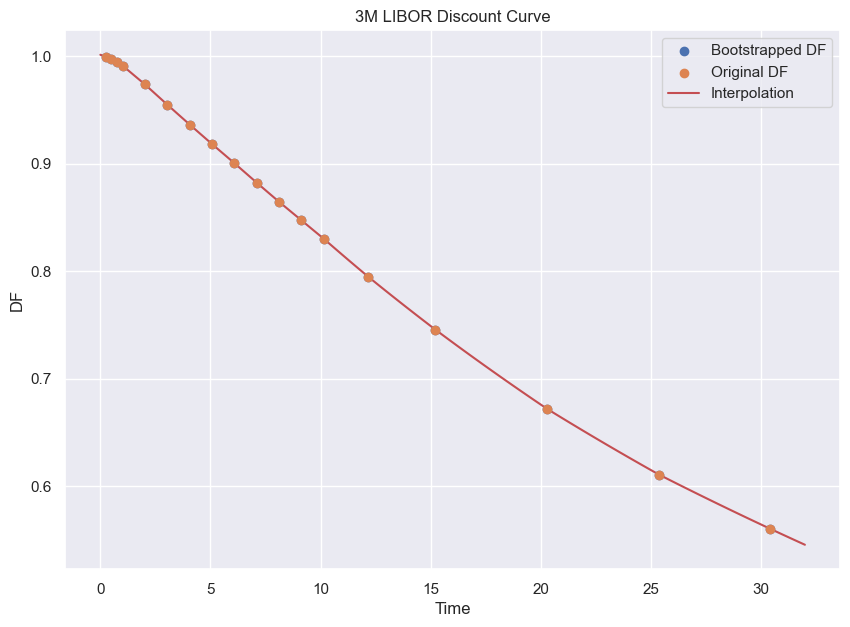

In [72]:
def getDfByTime(t):
    for idx, tt in enumerate(discountFactorsPeriods):
        if abs(tt - t) < 1e-9:
            return discountFactors[idx]
    return None

for j, maturityYears in enumerate(irsPeriods):
    swapRate = irsRates[j]  # par swap rate for N years

    fixedDates = []
    fixedAlphas = []
    for k in range(1, maturityYears + 1):
        dateK = calendar.advance(startDate, ql.Period(k, ql.Years))
        dateK = calendar.adjust(dateK, ql.Following)  # корректировка на рабочий день
        fixedDates.append(dateK)

        prevDate = calendar.advance(startDate, ql.Period(k - 1, ql.Years))
        prevDate = calendar.adjust(prevDate, ql.Following)
        alphaK = dayCount.yearFraction(prevDate, dateK)
        fixedAlphas.append(alphaK)

    # sum_{k=1..N-1} alpha_k * DF(t_k)
    sumKnown = 0.0
    for k in range(1, maturityYears):  # k = 1,...,N-1
        timeK = dayCount.yearFraction(startDate, fixedDates[k - 1])
        dfK = getDfByTime(timeK)
        if dfK is None:
            logInterp = interp1d(discountFactorsPeriods, np.log(discountFactors), 
                               kind='linear', fill_value="extrapolate")
            dfK = np.exp(logInterp(timeK))
        sumKnown += fixedAlphas[k - 1] * dfK

    alphaN = fixedAlphas[-1]
    timeN = dayCount.yearFraction(startDate, fixedDates[-1])

    # Use par swap relation:
    # S * (sumKnown + alpha_N * DF_N) = 1 - DF_N
    # => DF_N * (1 + S * alpha_N) = 1 - S * sumKnown
    dfN = (1.0 - swapRate * sumKnown) / (1.0 + swapRate * alphaN)

    discountFactors.append(dfN)
    discountFactorsPeriods.append(timeN)
    
    print(f"IRS {maturityYears}Y: rate = {swapRate:.4f}, DF = {dfN:.6f}, time = {timeN:.4f}")

discountFactorsPeriods = np.array(discountFactorsPeriods)
discountFactors = np.array(discountFactors)


sns.set(rc={"figure.figsize":(10, 7)})

plt.scatter(discountFactorsPeriods, discountFactors, label="Bootstrapped DF", zorder=2)

logDF = np.log(discountFactors)
linearInterpLog = interp1d(discountFactorsPeriods, logDF, kind='linear', fill_value="extrapolate")

def interpolatedValues(newX):
    logInterpValues = linearInterpLog(newX)
    return np.exp(logInterpValues)

newX = np.linspace(0, 32, 100)         
newY = interpolatedValues(newX)    

plt.scatter(discountFactorsPeriods, discountFactors, label="Original DF", zorder=2)
plt.plot(newX, newY, '-', label="Interpolation", c="r", zorder=1) 
plt.ylabel("DF")
plt.xlabel("Time")
plt.legend()
plt.title("3M LIBOR Discount Curve")
plt.grid(True)
plt.show()

In [73]:
discountFactors


array([0.99925888, 0.9973473 , 0.99455151, 0.99095751, 0.97350971,
       0.95463626, 0.93624102, 0.91816162, 0.90043081, 0.8822525 ,
       0.86439513, 0.84729627, 0.8301733 , 0.7947023 , 0.74564541,
       0.67201356, 0.61100896, 0.56051587])